In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import json
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

sns.set_style("whitegrid")

In [27]:
df = pd.read_csv("Smart_irrigation_dataset.csv")
df.head()

,crop_name,soil_type,crop_age_days,day_of_year,temperature_C,humidity_%,rainfall_mm,effective_rainfall_mm,solar_radiation_MJ_m2_day,wind_speed_m_s,...,soil_moisture_%,reference_evapotranspiration_ET0_mm_day,crop_coefficient_Kc,application_efficiency_%,root_zone_depth_m,available_water_content_mm_per_m,irrigation_interval_days,p_fraction,irrigate,irrigation_amount_m3
0,Tomato,Sandy,55,324,19.90,74.79,1.08,0.55,18.94,2.72,...,20.25,2.249,1.050,70.42,0.694,135.58,7,0.387,1,251.6741
1,Wheat,Silty,96,89,19.39,61.01,2.07,1.21,27.04,3.20,...,31.57,2.000,0.544,64.13,0.347,115.47,3,0.300,0,0.0000
2,Maize,Sandy,36,161,30.20,93.53,2.11,1.27,29.09,1.54,...,19.09,2.574,0.946,82.43,0.533,103.85,8,0.536,1,202.6717
3,Tomato,Silty,114,334,20.59,51.75,4.61,3.06,27.12,2.03,...,23.85,2.502,0.630,73.99,1.150,131.45,8,0.562,0,0.0000
4,Tomato,Silty,37,75,36.59,93.87,0.40,0.35,7.68,3.57,...,21.00,2.745,0.915,61.72,1.135,124.15,10,0.405,1,588.5058


In [ ]:
# Features pertinentes uniquement (capteurs + saisie utilisateur) — cibles: irrigate, water_amount (CSV: irrigation_amount_m3)
SENSOR_COLS = ["soil_moisture_%", "temperature_C", "humidity_%", "rainfall_mm"]
USER_COLS = ["crop_name", "soil_type", "crop_age_days"]
FEATURE_COLS = SENSOR_COLS + USER_COLS

missing = [c for c in FEATURE_COLS + ["irrigate", "irrigation_amount_m3"] if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV: {missing}")

X = df[FEATURE_COLS].copy()
y_class = df["irrigate"]
# Colonne CSV en litres réels (nom _m3 trompeur). Cible litres/cycle plante: sqrt(litres) pour éviter saturation au max.
_liters = df["irrigation_amount_m3"].astype(float)
y_reg = np.where(_liters <= 0, 0.0, np.clip(np.sqrt(_liters) / 22.0, 0.12, 1.8))

num_cols = SENSOR_COLS + ["crop_age_days"]
cat_cols = ["crop_name", "soil_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", MinMaxScaler()),
                ]
            ),
            num_cols,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

print("Variables numeriques (MinMax):", num_cols)
print("Variables categorielles (OneHot):", cat_cols)

Variables numeriques (MinMax): ['soil_moisture_%', 'temperature_C', 'humidity_%', 'rainfall_mm', 'crop_age_days']
Variables categorielles (OneHot): ['crop_name', 'soil_type']


In [29]:
# Split unique (meme echantillon pour classif et regression) + preprocess clone (evite ecrasement mutuel)
idx = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_class
)
X_train_c = X.iloc[train_idx]
X_test_c = X.iloc[test_idx]
y_train_c = y_class.iloc[train_idx]
y_test_c = y_class.iloc[test_idx]
y_train_r = y_reg.iloc[train_idx]
y_test_r = y_reg.iloc[test_idx]

# Petit reseau: 1 couche cachee, max 8 neurones (TinyML / ESP32)
clf_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(8,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
            ),
        ),
    ]
)

clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c = clf_pipeline.predict(X_test_c)

acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy (SmallNN - classification): {acc:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test_c, y_pred_c))

Accuracy (SmallNN - classification): 0.7810

Classification report:

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       892
           1       0.79      0.82      0.81      1108

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



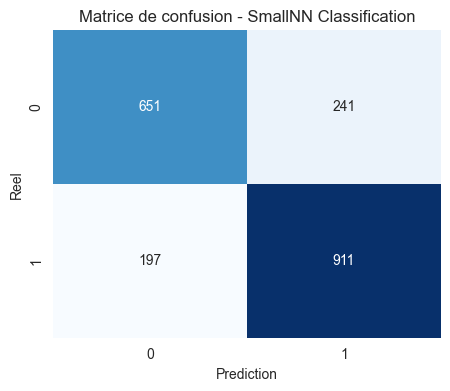

In [30]:
# Matrice de confusion classification
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matrice de confusion - SmallNN Classification")
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.show()

In [31]:
# Regression: meme split train/test que la classification
# Meme architecture legere pour la regression (cible litres 0-3 par cycle)
reg_pipeline = Pipeline(
    steps=[
        ("preprocess", clone(preprocessor)),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(8,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=500,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=20,
            ),
        ),
    ]
)

reg_pipeline.fit(X_train_c, y_train_r)
y_pred_r = reg_pipeline.predict(X_test_c)

mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"MSE  (SmallNN - regression / litres sqrt 0.12-1.8): {mse:.4f}")
print(f"MAE  (SmallNN - regression): {mae:.4f}")
print(f"RMSE (SmallNN - regression): {rmse:.4f}")
print(f"R2   (SmallNN - regression): {r2:.4f}")

MSE  (SmallNN - regression / water_amount): 47235.8010
MAE  (SmallNN - regression): 166.6391
RMSE (SmallNN - regression): 217.3380
R2   (SmallNN - regression): 0.3778


c:\Users\LENEVO\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [32]:
# Evaluation Tomato uniquement
mask_tomato_c = X_test_c["crop_name"] == "Tomato"
mask_tomato_r = X_test_c["crop_name"] == "Tomato"

if mask_tomato_c.sum() > 0:
    y_test_tomato_c = y_test_c[mask_tomato_c]
    y_pred_tomato_c = clf_pipeline.predict(X_test_c[mask_tomato_c])
    print(f"Accuracy Tomato (classification): {accuracy_score(y_test_tomato_c, y_pred_tomato_c):.4f}")
else:
    print("Aucune ligne Tomato dans X_test_c")

if mask_tomato_r.sum() > 0:
    y_test_tomato_r = y_test_r[mask_tomato_r]
    y_pred_tomato_r = reg_pipeline.predict(X_test_c[mask_tomato_r])
    print(f"MAE Tomato (regression): {mean_absolute_error(y_test_tomato_r, y_pred_tomato_r):.4f}")
    print(f"RMSE Tomato (regression): {np.sqrt(mean_squared_error(y_test_tomato_r, y_pred_tomato_r)):.4f}")
    print(f"R2 Tomato (regression): {r2_score(y_test_tomato_r, y_pred_tomato_r):.4f}")
else:
    print("Aucune ligne Tomato dans X_test_c")

Accuracy Tomato (classification): 0.7780
MAE Tomato (regression): 166.5834
RMSE Tomato (regression): 217.4355
R2 Tomato (regression): 0.3834


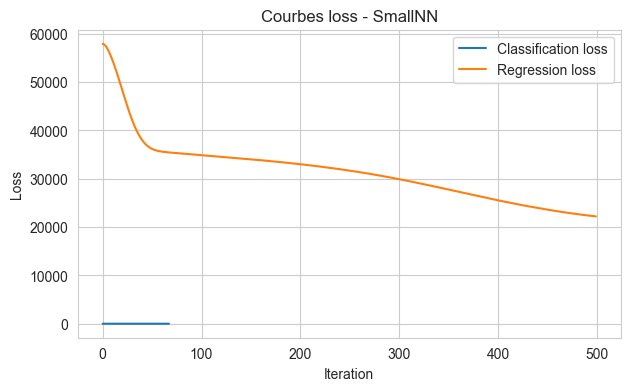

In [33]:
# Courbes d'apprentissage (loss) pour visualiser l'entrainement
clf_loss = clf_pipeline.named_steps["model"].loss_curve_
reg_loss = reg_pipeline.named_steps["model"].loss_curve_

plt.figure(figsize=(7, 4))
plt.plot(clf_loss, label="Classification loss")
plt.plot(reg_loss, label="Regression loss")
plt.title("Courbes loss - SmallNN")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

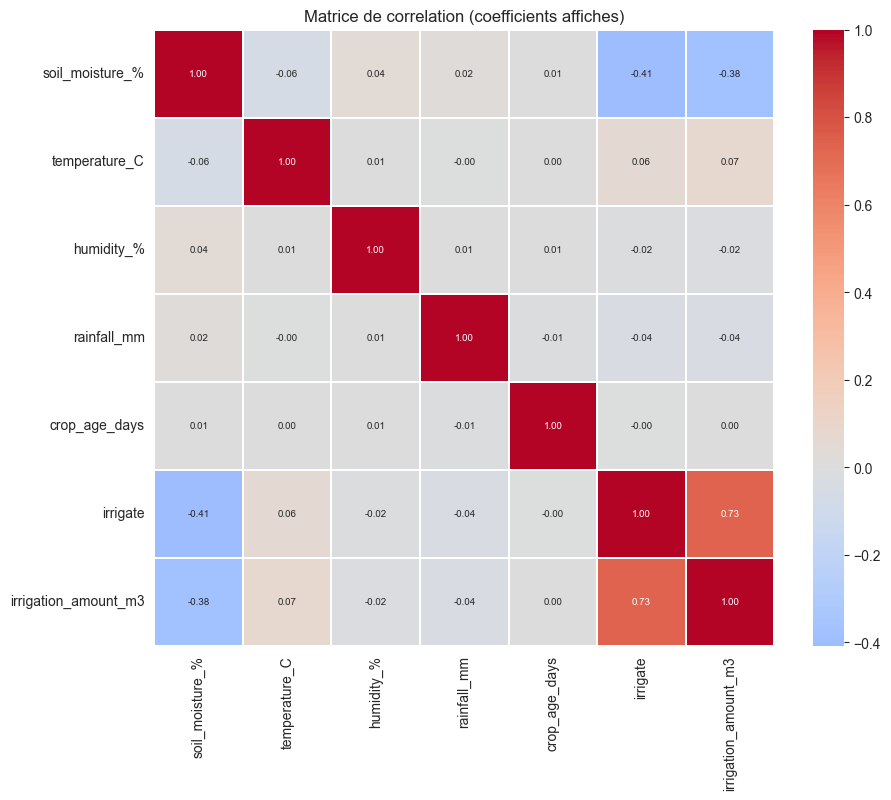

In [34]:
# Matrice de correlation (numeriques utiles + cibles)
corr_cols = SENSOR_COLS + ["crop_age_days", "irrigate", "irrigation_amount_m3"]
corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot_kws={"size": 7},
)
plt.title("Matrice de correlation (coefficients affiches)")
plt.show()

In [35]:
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


def _repo_root() -> Path:
    """Racine du projet (dossier contenant Smart_irrigation_dataset.csv)."""
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "Smart_irrigation_dataset.csv").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError("Smart_irrigation_dataset.csv introuvable (lancez depuis le projet).")


def _mlp_weights_to_c_header(mlp, path: Path, name_prefix: str) -> None:
    """Exporte les coefs/intercepts sklearn MLP en tableaux C float."""
    lines = [
        f"/* {name_prefix}: sklearn MLP — couches relu sauf sortie (identite ou logistique selon le modele) */",
        "/* Ordre des poids: W0, b0, W1, b1 ... (row-major C) */",
        "",
    ]
    for i, (w, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        w = np.asarray(w, dtype=np.float32)
        b = np.asarray(b, dtype=np.float32)
        flat_w = w.ravel(order="C")
        lines.append(f"static const float {name_prefix}_W{i}[{flat_w.size}] = {{")
        lines.append("  " + ", ".join(f"{x:.8f}f" for x in flat_w))
        lines.append("};")
        lines.append(f"static const float {name_prefix}_B{i}[{b.size}] = {{")
        lines.append("  " + ", ".join(f"{x:.8f}f" for x in b))
        lines.append("};")
        lines.append("")
    path.write_text("\n".join(lines), encoding="utf-8")


out_dir = _repo_root() / "smallNN" / "models"
out_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(clf_pipeline, out_dir / "smallnn_classifier.joblib")
joblib.dump(reg_pipeline, out_dir / "smallnn_regressor.joblib")

# Encodeur + scaler (pipeline preprocess complet)
joblib.dump(clf_pipeline.named_steps["preprocess"], out_dir / "smallnn_preprocessor.joblib")

pre = clf_pipeline.named_steps["preprocess"]
mm: MinMaxScaler = pre.named_transformers_["num"].named_steps["scaler"]
ohe: OneHotEncoder = pre.named_transformers_["cat"].named_steps["onehot"]
num_feature_names = list(pre.transformers_[0][2])
cat_feature_names = list(pre.transformers_[1][2])
scaler_meta = {
    "numeric_feature_names": num_feature_names,
    "data_min": mm.data_min_.tolist(),
    "data_max": mm.data_max_.tolist(),
    "scale": mm.scale_.tolist(),
    "min": mm.min_.tolist(),
    "onehot_feature_names_in": cat_feature_names,
    "onehot_categories": [np.asarray(c).tolist() for c in ohe.categories_],
}
(out_dir / "scaler_encoder_params.json").write_text(json.dumps(scaler_meta, indent=2), encoding="utf-8")

_mlp_weights_to_c_header(
    clf_pipeline.named_steps["model"], out_dir / "smallnn_classifier_weights.h", "SMALLNN_CLF"
)
_mlp_weights_to_c_header(
    reg_pipeline.named_steps["model"], out_dir / "smallnn_regressor_weights.h", "SMALLNN_REG"
)

print("Sauvegarder", out_dir.resolve())
for p in sorted(out_dir.iterdir()):
    if p.is_file():
        print(f"  {p.name} ({p.stat().st_size // 1024} Ko)")

Sauvegarder C:\Users\LENEVO\Desktop\11master pf\smallNN\models
  scaler_encoder_params.json (0 Ko)
  smallnn_classifier.joblib (13 Ko)
  smallnn_classifier_weights.h (1 Ko)
  smallnn_preprocessor.joblib (3 Ko)
  smallnn_regressor.joblib (26 Ko)
  smallnn_regressor_weights.h (1 Ko)
